# SIAN: Sparse Interaction Additive Network

SIAN represents main effects and selected higher-order interactions in a block-masked ReLU network. It can discover interactions with Archipelago or accept an explicit sparse term set.


## Model in one view


$$
\eta(x)=\beta_0+\sum_j f_j(x_j)+
\sum_{S\in\widehat{\mathcal I}} f_S(x_S),
$$

where $\widehat{\mathcal I}$ is selected from inclusion/removal contrasts of a reference network. Main effects are always retained.



SIAN represents candidate subsets of variables with masked network blocks and
uses a sparse selected frontier rather than fitting the full combinatorial
interaction lattice. Heredity rules constrain which higher-order terms can be
considered after lower-order evidence is found. Explicit term sets bypass
selection and turn SIAN into a known-structure additive interaction model.

Each selected subset owns one contribution, so the final predictor is still a
sum of named terms. The interaction detector and the final term estimator are
distinct stages: selection identifies a sparse support, while block-masked or
independent execution estimates the functions on that support.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


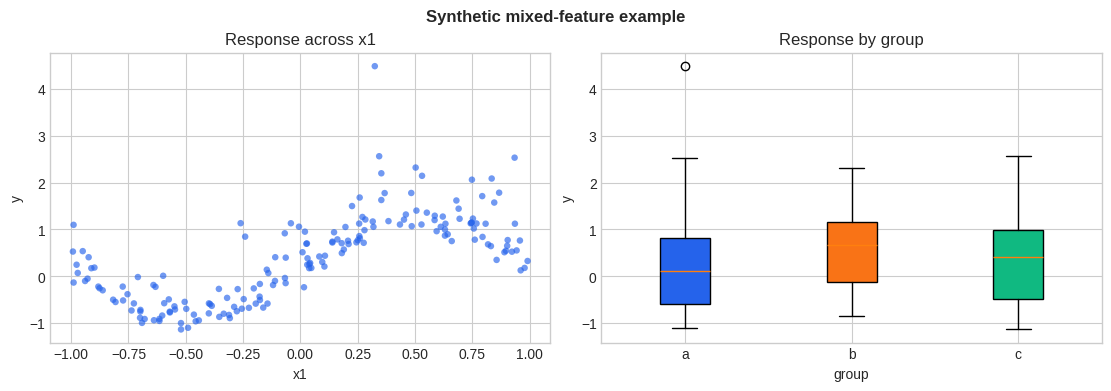

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import SIANClassifier, SIANLSS, SIANRegressor


# Explicit terms bypass discovery and keep this example inexpensive.
model = SIANRegressor(
    interactions=(("x1", "x2"),),
    layer_sizes=[16, 12, 8],
    execution_mode="block_masked",
    l1_regularization=5e-5,
)
model.get_params(deep=False)


{'activation': torch.nn.modules.activation.ReLU,
 'archipelago_baseline': 'pairwise',
 'dropout': 0.0,
 'execution_mode': 'block_masked',
 'feature_output_bias': True,
 'heredity_fraction': 0.5,
 'interaction_degree': None,
 'interaction_detector': 'archipelago',
 'interaction_thresholds': 0.1,
 'interactions': (('x1', 'x2'),),
 'intercept': True,
 'l1_regularization': 5e-05,
 'layer_sizes': [16, 12, 8],
 'lr': 0.005,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'lr_schedule': 'plateau',
 'max_candidates': 1000,
 'max_interaction_order': 3,
 'max_terms_per_order': None,
 'optimizer': 'adagrad',
 'reference_batch_size': 128,
 'reference_device': 'cpu',
 'reference_epochs': 100,
 'reference_layer_sizes': [256, 128, 64],
 'reference_lr': 0.005,
 'reference_weight_decay': 0.0,
 'residual_layer_sizes': [256, 128, 64],
 'residual_network': False,
 'selection_batch_size': 1024,
 'selection_max_pairs': 1024,
 'selection_max_samples': 128,
 'selection_output_index': 0,
 'threshold_mode': 'fraction',

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/m

{'R2': -0.18562751821124945, 'Mean Squared Error': 0.8274591243450319}

,term,term_type,output,importance
0,x1:x2,interaction,0,0.028944
1,x2,main,0,0.017209
2,group,main,0,0.011749
3,x1,main,0,0.009354


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.965,NaN,-0.021987,2,0.009354
1,x1,main,0,-0.8895,NaN,-0.021058,2,0.009354
2,x1,main,0,-0.7905,NaN,-0.016665,2,0.009354
3,x1,main,0,-0.6915,NaN,-0.014387,2,0.009354
4,x1,main,0,-0.58,NaN,-0.011226,2,0.009354
5,x1,main,0,-0.4875,NaN,-0.007094,2,0.009354
6,x1,main,0,-0.35,NaN,-0.000747,1,0.009354
7,x1,main,0,-0.209,NaN,0.000414,2,0.009354
8,x1,main,0,-0.12505,NaN,0.003146,2,0.009354
9,x1,main,0,-0.05205,NaN,0.004729,2,0.009354


## Evaluate and explain


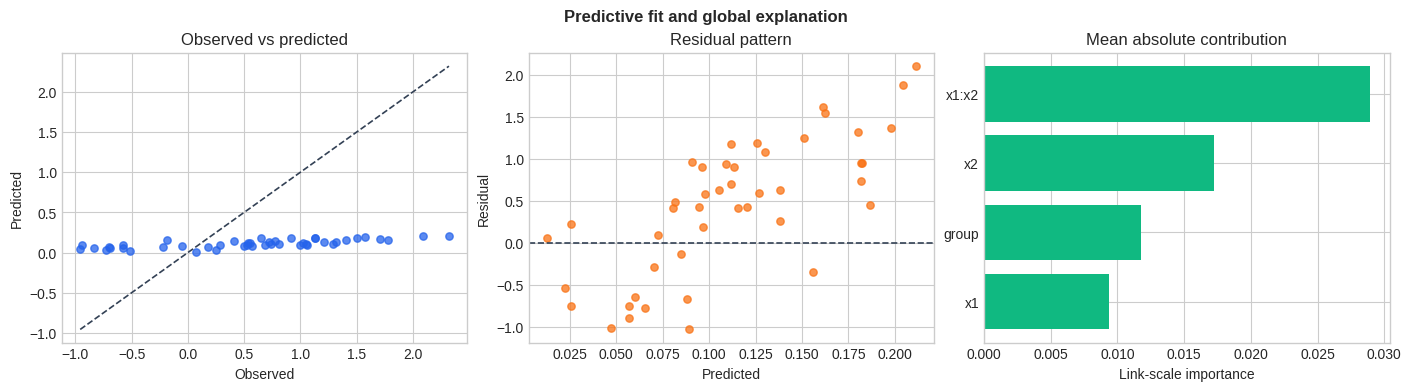

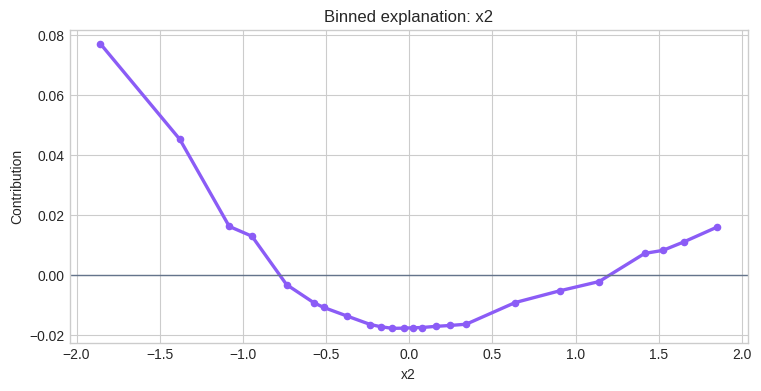

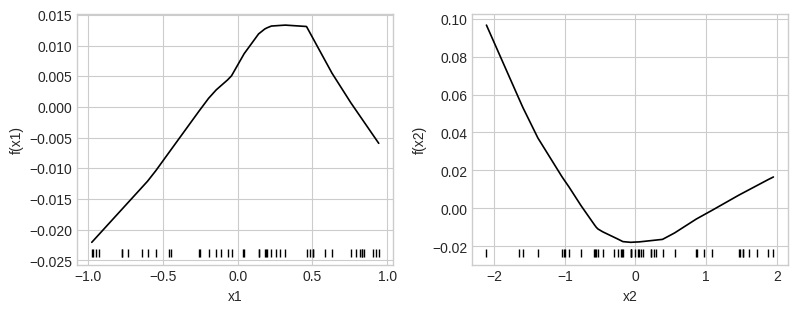

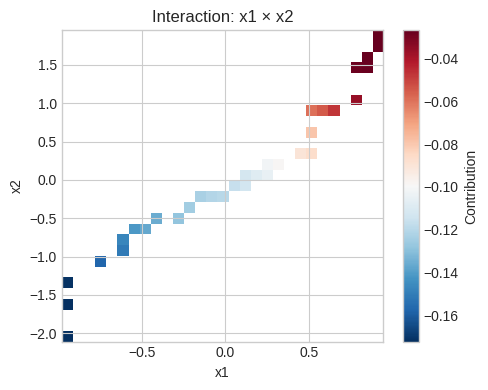

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

Without explicit `interactions`, configure `max_interaction_order`, thresholds, and heredity. Fitted models can switch losslessly between block-masked and independent term execution.


In [6]:
auto_model = SIANRegressor(
    max_interaction_order=2,
    interaction_thresholds=0.10,
    threshold_mode="fraction",
)
display(model.selected_interactions_)
model.compress_terms()
compressed = model.predict(X_test)
model.block_mask_terms()
np.testing.assert_allclose(compressed, model.predict(X_test), rtol=1e-5, atol=1e-5)
# For a fitted auto_model: auto_model.interaction_selection_table()


(('x1', 'x2'),)

## Supported task variants

`SIANRegressor`, `SIANClassifier`, and `SIANLSS` share interaction discovery and execution-mode controls.


In [7]:
task_variants = {"regression": SIANRegressor(), "classification": SIANClassifier(), "distributional": SIANLSS()}


## References

- [Tsang et al. (2022), Sparse Interaction Additive Networks](https://arxiv.org/abs/2209.09326).
